# Part B — Deep Learning Architectures

## B1: Artificial Neural Network (ANN)
### Diabetes Classification

This project implements an Artificial Neural Network (ANN) for binary classification using the Pima Indians Diabetes Dataset.

The objective is to predict the diabetes outcome based on medical and demographic features.

In [2]:
# Step 2: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Dataset Loading and Initial Inspection

The dataset is loaded using Pandas. Initial inspection is performed to understand its structure, features, target variable, and missing values.




In [3]:
# Step 2: Load and inspect the dataset

df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Dataset shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Step 3: Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the statistical characteristics of the dataset and the distribution of the target variable.

The analysis includes summary statistics, class distribution, and feature distributions.

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


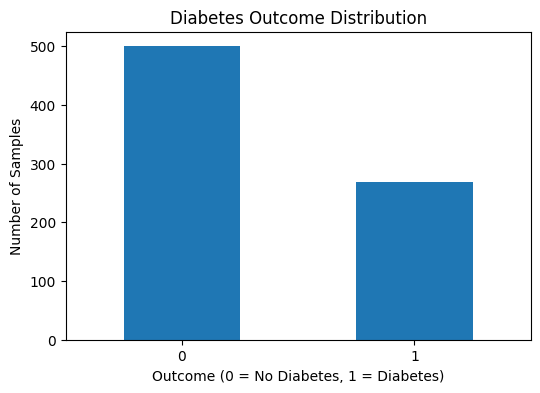

In [4]:
# Step 3: Exploratory Data Analysis

print("Statistical Summary:")
display(df.describe())

print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

# Plot target class distribution
plt.figure(figsize=(6, 4))
df["Outcome"].value_counts().sort_index().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## Step 5: Data Preprocessing

The input features and target variable are separated.

Zero values in selected medical measurements are treated as missing values and replaced with the median of each feature.

The data is then divided into training and testing sets and standardized using StandardScaler.

In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

columns_with_invalid_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace invalid zero values with NaN
X[columns_with_invalid_zero] = X[columns_with_invalid_zero].replace(0, np.nan)

# Fill missing values with median
X = X.fillna(X.median())

print("Missing values after preprocessing:")
print(X.isnull().sum())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Training samples: 614
Testing samples: 154
Number of features: 8


## Step 6: Building the Artificial Neural Network

An Artificial Neural Network is created using fully connected Dense layers.

The network contains two hidden layers with ReLU activation and a final output layer with sigmoid activation for binary classification.


In [6]:
ann_model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

d:\install\python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Training the ANN Model

The ANN model is trained using the training dataset.

The Adam optimizer is used with binary cross-entropy loss. Validation data is used to monitor the model's performance during training.

In [7]:
history = ann_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

print("ANN training completed successfully!")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4990 - loss: 0.6989 - val_accuracy: 0.5935 - val_loss: 0.6498
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6415 - loss: 0.6496 - val_accuracy: 0.7724 - val_loss: 0.6112
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7006 - loss: 0.6368 - val_accuracy: 0.7967 - val_loss: 0.5796
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7047 - loss: 0.6170 - val_accuracy: 0.8049 - val_loss: 0.5555
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7128 - loss: 0.5929 - val_accuracy: 0.8130 - val_loss: 0.5320
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7149 - loss: 0.5798 - val_accuracy: 0.8049 - val_loss: 0.5099
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7699 - loss: 0.5523 - val_accuracy: 0.8049 - val_loss: 0.4916
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7454 - loss: 0.5459 - val_accuracy: 0.8130 - val_loss

## Step 8: Training and Validation Curves

The training and validation accuracy and loss are visualized to analyze the learning behavior of the ANN model over the training epochs.

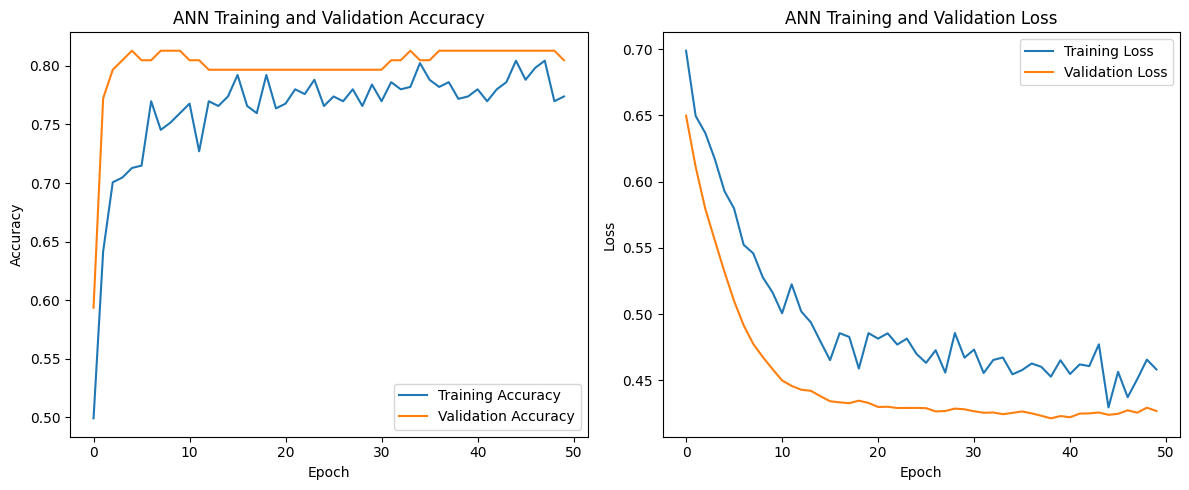

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 9: ANN Model Evaluation

The trained ANN model is evaluated on the unseen test dataset using accuracy, precision, recall, and F1-score.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict probabilities
y_prob = ann_model.predict(X_test)

# Convert probabilities into class labels
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ANN Test Set Performance")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
ANN Test Set Performance
-----------------------------------
Accuracy : 0.7338
Precision: 0.6226
Recall   : 0.6111
F1-Score : 0.6168

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



## Step 10: Confusion Matrix

A confusion matrix is generated to visualize the correct and incorrect predictions made by the ANN model on the test dataset.


Confusion Matrix:
[[80 20]
 [21 33]]


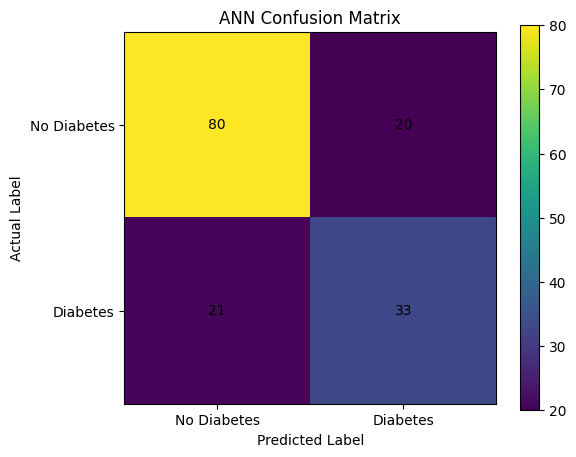

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()